# QS-Net: MAQT Quantum Classifier -- CICIoT (trained with `scripts/` package)

This notebook trains and evaluates the QS-Net model **using the `scripts/` package**
(`circuit.py`, `loss.py`, `prototypes.py`, `train.py`, `conformal.py`, `inference.py`,
`attacks.py`, `hilbert.py`, `sweep.py`, `logging.py`, ...) instead of re-implementing
the algorithms inline.

Pipeline:
1. Setup + locate the `scripts` package
2. Load & clean data, select classes, balance
3. Scale -> PCA -> angle-encode features
4. Build the quantum circuit + barren-plateau check (`circuit.py`, `gradient.py`)
5. Train with MAQT loss (`train.py`, `loss.py`, `prototypes.py`)
6. H1 Hilbert-geometry diagnostics (`hilbert.py`)
7. Test-set evaluation
8. Conformal zero-day threshold calibration -- Algorithm 2 (`conformal.py`)
9. Unified inference with rejection -- Algorithm 3 (`inference.py`)
10. Adversarial robustness: FGSM / PGD (`attacks.py`)
11. Lambda1 / Lambda2 hyperparameter sweep (`sweep.py`)
12. Final retrain + checkpoint + logs (`logging.py`)

## 1. Setup -- install deps, locate `scripts/`, imports, seeds

In [1]:
import warnings
warnings.filterwarnings("ignore")

!pip install pennylane pennylane-lightning --upgrade -q

import os, sys, json, pickle, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sns.set_style("whitegrid")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 51.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 61.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 87.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.9 MB/s eta 0:00:00
Using device: cuda:0


In [2]:
import sys


package_path = "/kaggle/input/datasets/arjunenaik/models"
if package_path not in sys.path:
    sys.path.append(package_path)


import scripts
print(scripts.__file__)



/kaggle/input/datasets/arjunenaik/models/scripts/__init__.py


In [10]:
from scripts.constants import (
    DEFAULT_ALPHA, DEFAULT_CF, DEFAULT_NOISE_RATE, ZERO_DAY,
    DEFAULT_LAMBDA1, DEFAULT_LAMBDA2, BARREN_PLATEAU_VAR_THRESHOLD,
)

In [3]:
# ---- Import everything we need from the scripts package ----

from scripts.constants import (
    DEFAULT_ALPHA, DEFAULT_CF, DEFAULT_NOISE_RATE, ZERO_DAY,
    DEFAULT_LAMBDA1, DEFAULT_LAMBDA2, BARREN_PLATEAU_VAR_THRESHOLD,
)
from scripts.data import (
    class_balance_table, class_weights_for_sampler, capped_sample,
    stratified_head, plot_class_balance_bars, plot_class_balance_pie,
)
from scripts.circuit import create_quantum_device, build_forward_circuit, initialize_random_weights
from scripts.gradient import gradient_variance_probe
from scripts.train import train_maqt, train_plain_vqc
from scripts.hilbert import hilbert_geometry_diagnostics, print_h1_report, fidelity_gap_proxy
from scripts.quantum_metrics import fidelity, trace_distance
from scripts.inference import predict_labels, estimate_lipschitz, qsnet_infer_batch
from scripts.conformal import calibrate_threshold, nonconformity_score
from scripts.attacks import fgsm_attack, pgd_attack, eval_attacked, robustness_ablation
from scripts.sweep import run_sweep, default_score_fn
from scripts.logging import write_history_log, write_sweep_log, to_jsonable
from scripts.utils import to_np_batch_x, to_np_y

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support,
)

print("scripts package imported successfully.")

scripts package imported successfully.


## 2. Load the raw dataset

In [4]:
DATA_PATH = "/kaggle/input/datasets/arjunenaik/cicio-p8/CICIO_p8"

df_train   = pd.read_parquet(f"{DATA_PATH}/q8_train.parquet")
df_test    = pd.read_parquet(f"{DATA_PATH}/q8_test.parquet")
df_cal     = pd.read_parquet(f"{DATA_PATH}/q8_calibration.parquet")
df_zeroday = pd.read_parquet(f"{DATA_PATH}/q8_zeroday.parquet")

for name, df in [("train", df_train), ("test", df_test), ("cal", df_cal), ("zeroday", df_zeroday)]:
    print(f"{name:8s}: {df.shape}")

df_train.head()

train   : (132166, 11)
test    : (18883, 11)
cal     : (18883, 11)
zeroday : (10984, 11)


,urg_count,Duration,flow_duration,Variance,Std,HTTPS,Tot sum,Header_Length,label_multiclass,label_binary,label_family
0,0.022648,2.364978,0.003637,0.000000,0.017957,0.000000,1.057962,0.860762,DDoS-RSTFINFlood,1,ddos
1,1.162439,3.045862,0.378237,2.909113,1.699442,3.141593,1.142228,2.621899,BenignTraffic,0,benign
2,0.000000,2.364978,0.000000,0.000000,0.000000,0.000000,0.944141,0.000000,DDoS-ICMP_Flood,1,ddos
3,0.000000,2.363669,0.000071,0.472997,0.679082,0.000000,1.075915,0.791950,DDoS-TCP_Flood,1,ddos
4,0.000000,2.364978,0.000000,0.000000,0.000000,0.000000,1.057771,0.782123,DDoS-RSTFINFlood,1,ddos


In [5]:
df_train.info()
print("\nMissing values per column (train, top 10):")
print(df_train.isna().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132166 entries, 0 to 132165
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   urg_count         132166 non-null  float64
 1   Duration          132166 non-null  float64
 2   flow_duration     132166 non-null  float64
 3   Variance          132166 non-null  float64
 4   Std               132166 non-null  float64
 5   HTTPS             132166 non-null  float64
 6   Tot sum           132166 non-null  float64
 7   Header_Length     132166 non-null  float64
 8   label_multiclass  132166 non-null  object 
 9   label_binary      132166 non-null  int8   
 10  label_family      132166 non-null  object 
dtypes: float64(8), int8(1), object(2)
memory usage: 10.2+ MB

Missing values per column (train, top 10):
urg_count           0
Duration            0
flow_duration       0
Variance            0
Std                 0
HTTPS               0
Tot sum             0
Heade

In [6]:
print("Raw train multiclass distribution:")
df_train.label_multiclass.value_counts()

Raw train multiclass distribution:


label_multiclass
DDoS-ICMP_Flood            21177
DDoS-UDP_Flood             15878
DDoS-TCP_Flood             13249
DDoS-PSHACK_Flood          11988
DDoS-SYN_Flood             11947
DDoS-RSTFINFlood           11816
DDoS-SynonymousIP_Flood    10561
DoS-UDP_Flood               9711
DoS-TCP_Flood               7803
DoS-SYN_Flood               5947
BenignTraffic               3202
DDoS-ICMP_Fragmentation     1331
DoS-HTTP_Flood              1271
MITM-ArpSpoofing             901
DDoS-UDP_Fragmentation       840
DDoS-ACK_Fragmentation       837
VulnerabilityScan            630
DNS_Spoofing                 530
DDoS-HTTP_Flood              491
DDoS-SlowLoris               431
Recon-HostDiscovery          405
Recon-OSScan                 289
Recon-PortScan               242
DictionaryBruteForce         201
BrowserHijacking             109
SqlInjection                 101
CommandInjection              93
Backdoor_Malware              66
XSS                           63
Recon-PingSweep           

## 3. Clean data, select classes, balance the training split

In [7]:
# --- drop columns we don't use, keep only label_multiclass ---
for df in [df_train, df_test, df_cal, df_zeroday]:
    df.drop(columns=["label_family", "label_binary"], inplace=True, errors="ignore")

# --- handle missing / infinite values in the feature columns ---
def clean_features(df, feature_cols):
    df = df.copy()
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    n_before = len(df)
    df = df[df[feature_cols].isna().mean(axis=1) < 0.5]          # drop rows that are mostly NaN
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median(numeric_only=True))
    df[feature_cols] = df[feature_cols].fillna(0.0)               # anything still NaN -> 0
    n_after = len(df)
    if n_after < n_before:
        print(f"  dropped {n_before - n_after} rows with excessive missing values")
    return df.reset_index(drop=True)

_feature_cols_raw = [c for c in df_train.columns if c != "label_multiclass"]
df_train   = clean_features(df_train,   _feature_cols_raw)
df_test    = clean_features(df_test,    _feature_cols_raw)
df_cal     = clean_features(df_cal,     _feature_cols_raw)
df_zeroday = clean_features(df_zeroday, _feature_cols_raw)

# --- pick the top-N most frequent classes for training/eval ---
MAX_CLASSES = 10
top_classes = (
    df_train.label_multiclass.value_counts().head(MAX_CLASSES).index.tolist()
    if MAX_CLASSES else df_train.label_multiclass.unique().tolist()
)
print(f"Using top {len(top_classes)} classes: {top_classes}")

df_train_f   = df_train[df_train.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_test_f    = df_test[df_test.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_cal_f     = df_cal[df_cal.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_zeroday_f = df_zeroday.reset_index(drop=True)     # zero-day = unseen classes, kept as-is

le = LabelEncoder()
le.fit(top_classes)
CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)
print(f"Encoded classes ({N_CLASSES}): {dict(enumerate(CLASS_NAMES))}")

feature_columns = [c for c in df_train.columns if c != "label_multiclass"]
target_column = "label_multiclass"

Using top 10 classes: ['DDoS-ICMP_Flood', 'DDoS-UDP_Flood', 'DDoS-TCP_Flood', 'DDoS-PSHACK_Flood', 'DDoS-SYN_Flood', 'DDoS-RSTFINFlood', 'DDoS-SynonymousIP_Flood', 'DoS-UDP_Flood', 'DoS-TCP_Flood', 'DoS-SYN_Flood']
Encoded classes (10): {0: np.str_('DDoS-ICMP_Flood'), 1: np.str_('DDoS-PSHACK_Flood'), 2: np.str_('DDoS-RSTFINFlood'), 3: np.str_('DDoS-SYN_Flood'), 4: np.str_('DDoS-SynonymousIP_Flood'), 5: np.str_('DDoS-TCP_Flood'), 6: np.str_('DDoS-UDP_Flood'), 7: np.str_('DoS-SYN_Flood'), 8: np.str_('DoS-TCP_Flood'), 9: np.str_('DoS-UDP_Flood')}


In [8]:
# --- balance training data with scripts.data.capped_sample (per-class cap, no forced downsampling) ---
PER_CLASS_CAP = 100
CAL_TEST_CAP  = 4000
ZERODAY_CAP   = 2000

X_train_raw = df_train_f[feature_columns].values
y_train_raw = le.transform(df_train_f[target_column])

X_train, y_train = capped_sample(X_train_raw, y_train_raw, per_class_cap=PER_CLASS_CAP, seed=SEED)

X_test_raw = df_test_f[feature_columns].values
y_test_raw = le.transform(df_test_f[target_column])
X_test, y_test = stratified_head(X_test_raw, y_test_raw, n=CAL_TEST_CAP, seed=SEED)

X_cal_raw = df_cal_f[feature_columns].values
y_cal_raw = le.transform(df_cal_f[target_column])
X_cal, y_cal = stratified_head(X_cal_raw, y_cal_raw, n=CAL_TEST_CAP, seed=SEED)

X_zeroday = df_zeroday_f[feature_columns].values[:ZERODAY_CAP]

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}  X_cal: {X_cal.shape}  X_zeroday: {X_zeroday.shape}")

class_balance_table(y_train, CLASS_NAMES)

X_train: (1000, 8)  X_test: (4000, 8)  X_cal: (4000, 8)  X_zeroday: (2000, 8)


,class,count,pct
0,DDoS-ICMP_Flood,100,10.0
1,DDoS-PSHACK_Flood,100,10.0
2,DDoS-RSTFINFlood,100,10.0
3,DDoS-SYN_Flood,100,10.0
4,DDoS-SynonymousIP_Flood,100,10.0
5,DDoS-TCP_Flood,100,10.0
6,DDoS-UDP_Flood,100,10.0
7,DoS-SYN_Flood,100,10.0
8,DoS-TCP_Flood,100,10.0
9,DoS-UDP_Flood,100,10.0


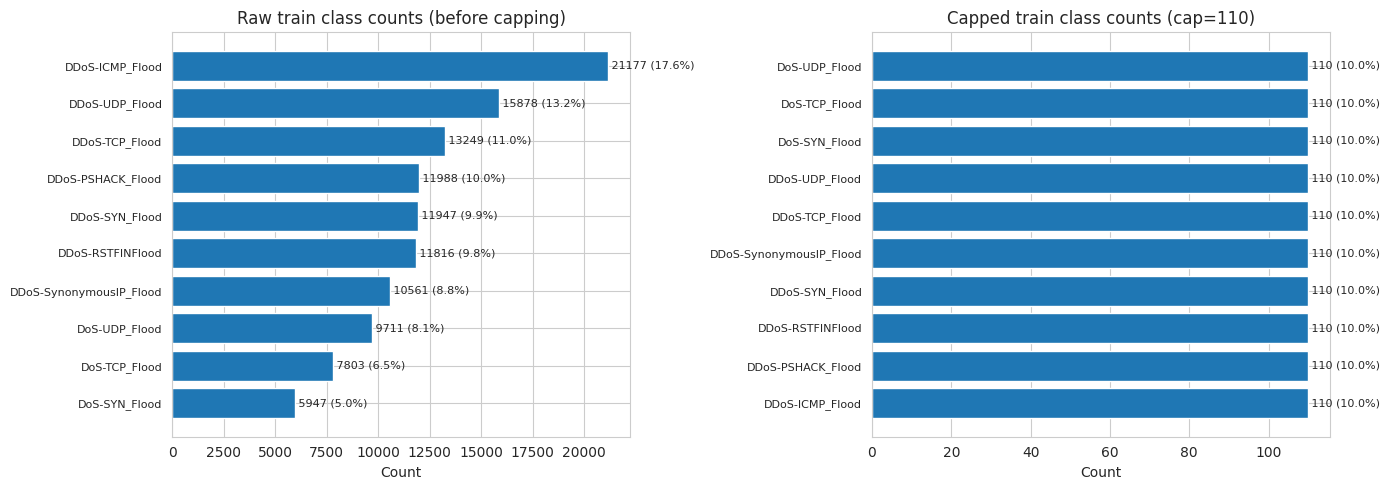

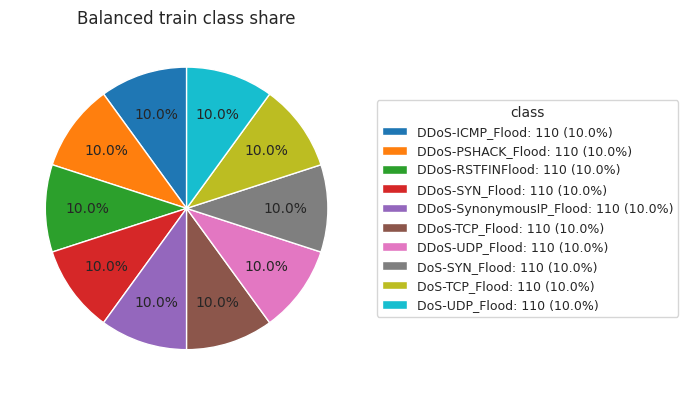

In [17]:
# --- visualize class balance: raw vs. capped/balanced train, using scripts.data plotting helpers ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_class_balance_bars(y_train_raw, CLASS_NAMES, title="Raw train class counts (before capping)", ax=ax[0])
plot_class_balance_bars(y_train, CLASS_NAMES, title=f"Capped train class counts (cap={PER_CLASS_CAP})", ax=ax[1])

plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
plot_class_balance_pie(y_train, CLASS_NAMES, title="Balanced train class share", ax=ax)
plt.tight_layout(); plt.show()

## 4. Scale -> PCA -> angle-encode
PCA components are fixed to `N_QUBITS` so the feature vector can be embedded 1:1 by `AngleEmbedding` in `circuit.py`.

In [9]:
N_QUBITS = 6  # also = number of PCA components kept
N_LAYERS = 3
NOISE_P  = DEFAULT_NOISE_RATE

scaler = StandardScaler()
X_train_scaled   = scaler.fit_transform(X_train)
X_test_scaled    = scaler.transform(X_test)
X_cal_scaled     = scaler.transform(X_cal)
X_zeroday_scaled = scaler.transform(X_zeroday)

pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca   = pca.fit_transform(X_train_scaled)
X_test_pca    = pca.transform(X_test_scaled)
X_cal_pca     = pca.transform(X_cal_scaled)
X_zeroday_pca = pca.transform(X_zeroday_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"PCA components kept: {N_QUBITS} (= N_QUBITS)")
print(f"Cumulative explained variance @ {N_QUBITS} comps: {cum_var[-1]*100:.2f}%")

def to_angles(X):
    Xc = np.clip(X, -3, 3)
    return (Xc + 3) / 6 * np.pi          # map to [0, pi] for angle embedding

A_train   = to_angles(X_train_pca)
A_test    = to_angles(X_test_pca)
A_cal     = to_angles(X_cal_pca)
A_zeroday = to_angles(X_zeroday_pca)

N_FEATURES = A_train.shape[1]
print(f"\nA_train: {A_train.shape}  N_FEATURES = {N_FEATURES}  N_CLASSES = {N_CLASSES}")

Original feature count: 8
PCA components kept: 6 (= N_QUBITS)
Cumulative explained variance @ 6 comps: 91.68%

A_train: (1000, 6)  N_FEATURES = 6  N_CLASSES = 10


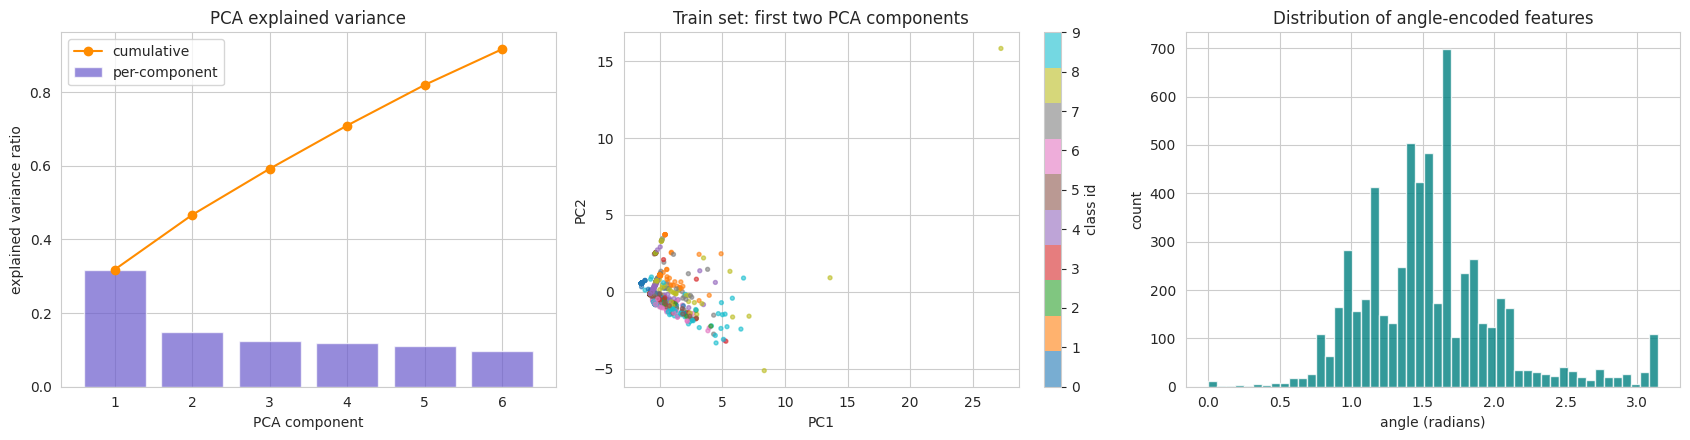

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

ax[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_,
          color="slateblue", alpha=0.7, label="per-component")
ax[0].plot(range(1, len(cum_var) + 1), cum_var, marker="o", color="darkorange", label="cumulative")
ax[0].set_xlabel("PCA component"); ax[0].set_ylabel("explained variance ratio")
ax[0].set_title("PCA explained variance"); ax[0].legend()

sc = ax[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="tab10", s=8, alpha=0.6)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].set_title("Train set: first two PCA components")
plt.colorbar(sc, ax=ax[1], ticks=range(N_CLASSES), label="class id")

ax[2].hist(A_train.flatten(), bins=50, color="teal", alpha=0.8)
ax[2].set_xlabel("angle (radians)"); ax[2].set_ylabel("count")
ax[2].set_title("Distribution of angle-encoded features")

plt.tight_layout(); plt.show()

## 5. Quantum circuit + barren-plateau check
Using `circuit.py::create_quantum_device` / `build_forward_circuit` and `gradient.py::gradient_variance_probe`.

In [11]:
dev = create_quantum_device(N_QUBITS, backend="default.mixed")
forward_circuit = build_forward_circuit(dev, N_QUBITS, N_LAYERS, noise_rate=NOISE_P, reupload=True)

print(f"Quantum device: {dev.name}, wires={N_QUBITS}, layers={N_LAYERS}, noise_rate={NOISE_P}")

Quantum device: default.mixed, wires=6, layers=3, noise_rate=0.01


[grad-variance probe] mean=7.639e-05  var=2.139e-07  (BARREN PLATEAU RISK)


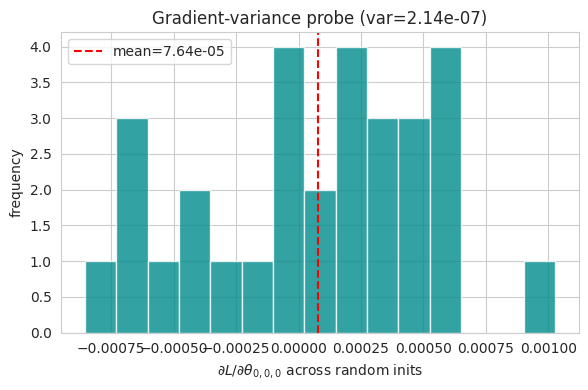

In [12]:
grad_var, grad_samples = gradient_variance_probe(
    forward_circuit, A_train[:8], n_qubits=N_QUBITS, n_layers=N_LAYERS,
    n_trials=30, device=device,
)
status = "OK" if grad_var > BARREN_PLATEAU_VAR_THRESHOLD else "BARREN PLATEAU RISK"
print(f"[grad-variance probe] mean={grad_samples.mean():.3e}  var={grad_var:.3e}  ({status})")

plt.figure(figsize=(6, 4))
plt.hist(grad_samples, bins=15, color="darkcyan", alpha=0.8)
plt.axvline(grad_samples.mean(), color="red", linestyle="--", label=f"mean={grad_samples.mean():.2e}")
plt.xlabel(r"$\partial L / \partial \theta_{0,0,0}$ across random inits")
plt.ylabel("frequency")
plt.title(f"Gradient-variance probe (var={grad_var:.2e})")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Train with MAQT loss
Using `train.py::train_maqt` (wraps `loss.py`, `prototypes.py`, curriculum warm-up, weighted sampling, gradient clipping).

In [13]:
LR             = 0.05
EPOCHS         = 10
BATCH_SIZE     = 16
LAMBDA1_MAX    = DEFAULT_LAMBDA1
LAMBDA2_MAX    = DEFAULT_LAMBDA2

theta, head, prototypes, ema_protos, history = train_maqt(
    A_train, y_train, n_classes=N_CLASSES, n_qubits=N_QUBITS, n_layers=N_LAYERS,
    forward_circuit=forward_circuit, device=device,
    epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    lambda1_max=LAMBDA1_MAX, lambda2_max=LAMBDA2_MAX,
    use_weighted_sampler=True, log_every=1, verbose=True,
)

epoch  1/10 | loss 1.9076 | L_CE 1.9076 | L_intra 0.3580 | L_inter -0.6061 | grad_var 1.36e-03 | intra_fid 0.642 | inter_TD 0.595 | time 51.7s
epoch  2/10 | loss 1.4350 | L_CE 1.4457 | L_intra 0.3147 | L_inter -0.5955 | grad_var 3.10e-03 | intra_fid 0.685 | inter_TD 0.573 | time 51.0s
epoch  3/10 | loss 1.3079 | L_CE 1.3302 | L_intra 0.3065 | L_inter -0.5851 | grad_var 4.31e-03 | intra_fid 0.694 | inter_TD 0.578 | time 51.2s
epoch  5/10 | loss 1.1764 | L_CE 1.2012 | L_intra 0.3019 | L_inter -0.5859 | grad_var 6.18e-03 | intra_fid 0.698 | inter_TD 0.577 | time 51.2s
epoch  6/10 | loss 1.1702 | L_CE 1.1978 | L_intra 0.2880 | L_inter -0.5718 | grad_var 6.26e-03 | intra_fid 0.712 | inter_TD 0.581 | time 51.0s
epoch  7/10 | loss 1.2348 | L_CE 1.2496 | L_intra 0.3150 | L_inter -0.5744 | grad_var 6.28e-03 | intra_fid 0.685 | inter_TD 0.568 | time 51.3s
epoch  8/10 | loss 1.1894 | L_CE 1.2082 | L_intra 0.3079 | L_inter -0.5760 | grad_var 7.12e-03 | intra_fid 0.692 | inter_TD 0.587 | time 51.0s

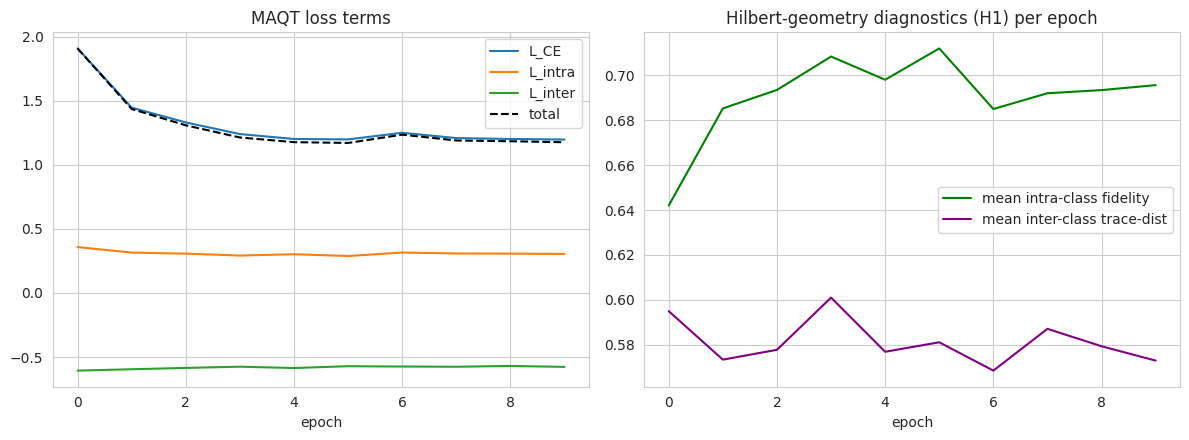

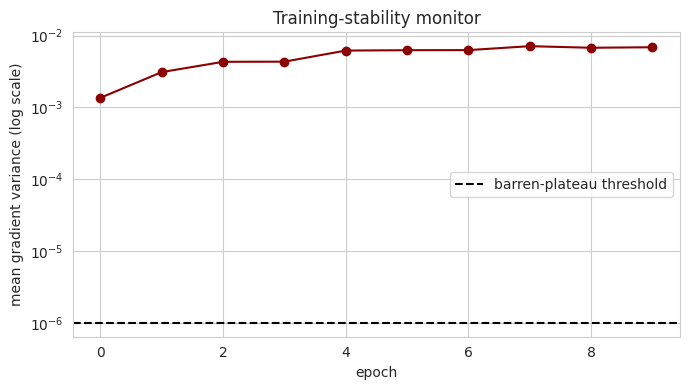

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(history["L_CE"], label="L_CE")
ax[0].plot(history["L_intra"], label="L_intra")
ax[0].plot(history["L_inter"], label="L_inter")
ax[0].plot(history["loss"], label="total", linestyle="--", color="black")
ax[0].set_title("MAQT loss terms"); ax[0].set_xlabel("epoch"); ax[0].legend()

ax[1].plot(history["intra_fid_gap"], label="mean intra-class fidelity", color="green")
ax[1].plot(history["inter_trace_dist"], label="mean inter-class trace-dist", color="purple")
ax[1].set_title("Hilbert-geometry diagnostics (H1) per epoch"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["grad_var"], marker="o", color="darkred")
plt.axhline(BARREN_PLATEAU_VAR_THRESHOLD, color="black", linestyle="--", label="barren-plateau threshold")
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("mean gradient variance (log scale)")
plt.title("Training-stability monitor"); plt.legend(); plt.tight_layout(); plt.show()

## 7. H1 Hilbert-geometry diagnostics on the test set
Using `hilbert.py::hilbert_geometry_diagnostics` + `print_h1_report`.

In [17]:
h1_report = hilbert_geometry_diagnostics(
    theta, A_test, y_test, prototypes, forward_circuit,
    class_names=CLASS_NAMES, device=device, batch_size=16,
)
print_h1_report(h1_report)

=== H1 Hilbert geometry (fidelity gaps) ===
mean intra-class fidelity : 0.7265
mean inter-class fidelity : 0.5767
fidelity gap (intra-inter): 0.1498  ← want ↑
mean inter trace distance : 0.5600  ← want ↑

per-class intra fidelity:
  DDoS-ICMP_Flood              n= 705  F=0.9175
  DDoS-PSHACK_Flood            n= 399  F=0.8147
  DDoS-RSTFINFlood             n= 394  F=0.8596
  DDoS-SYN_Flood               n= 398  F=0.7591
  DDoS-SynonymousIP_Flood      n= 352  F=0.7127
  DDoS-TCP_Flood               n= 441  F=0.8280
  DDoS-UDP_Flood               n= 529  F=0.8327
  DoS-SYN_Flood                n= 198  F=0.5276
  DoS-TCP_Flood                n= 260  F=0.5226
  DoS-UDP_Flood                n= 324  F=0.4910


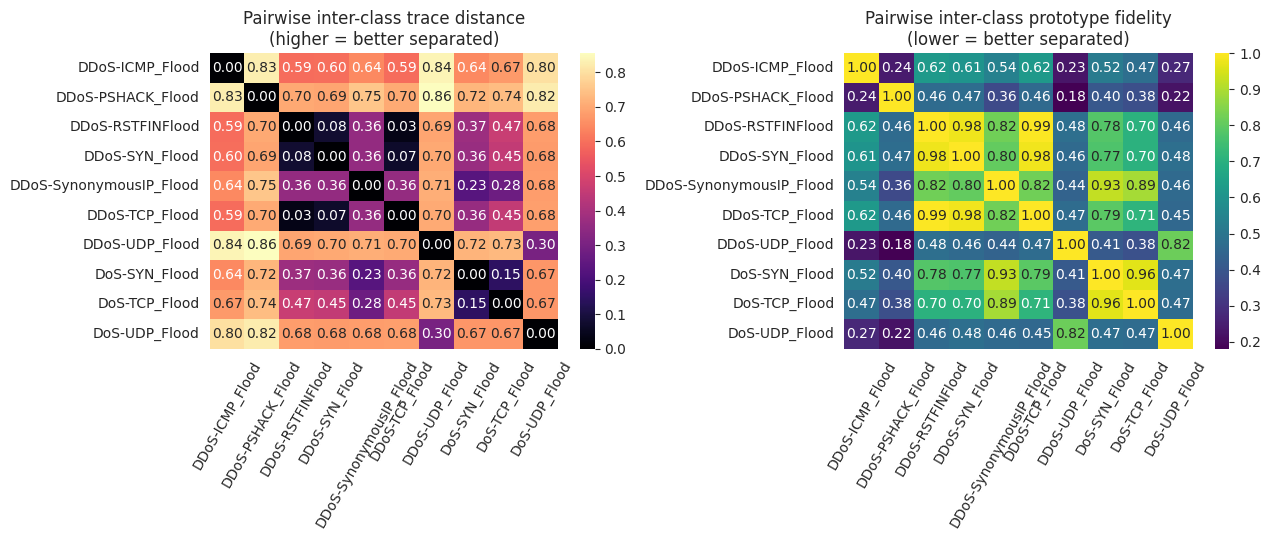

In [18]:
class_ids = sorted(prototypes)
n = len(class_ids)
td_matrix = np.zeros((n, n))
fid_matrix = np.eye(n)
for i, ci in enumerate(class_ids):
    for j, cj in enumerate(class_ids):
        if i == j:
            continue
        td_matrix[i, j] = float(trace_distance(prototypes[ci], prototypes[cj]))
        fid_matrix[i, j] = float(fidelity(prototypes[ci], prototypes[cj]))

labels = [CLASS_NAMES[c] for c in class_ids]
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
sns.heatmap(td_matrix, annot=True, fmt=".2f", cmap="magma", xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title("Pairwise inter-class trace distance\n(higher = better separated)")
ax[0].tick_params(axis="x", rotation=60)

sns.heatmap(fid_matrix, annot=True, fmt=".2f", cmap="viridis", xticklabels=labels, yticklabels=labels, ax=ax[1])
ax[1].set_title("Pairwise inter-class prototype fidelity\n(lower = better separated)")
ax[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

## 8. Test-set evaluation
Using `inference.py::predict_labels`.

In [19]:
y_true_test, y_pred_test = predict_labels(A_test, y_test, theta, head, forward_circuit, device=device, batch_size=64)
print(classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES, zero_division=0))

                         precision    recall  f1-score   support

        DDoS-ICMP_Flood       0.97      0.96      0.97       705
      DDoS-PSHACK_Flood       0.97      0.96      0.96       399
       DDoS-RSTFINFlood       0.00      0.00      0.00       394
         DDoS-SYN_Flood       0.24      0.70      0.35       398
DDoS-SynonymousIP_Flood       0.92      0.38      0.54       352
         DDoS-TCP_Flood       0.00      0.00      0.00       441
         DDoS-UDP_Flood       0.75      0.91      0.82       529
          DoS-SYN_Flood       0.11      0.21      0.15       198
          DoS-TCP_Flood       0.27      0.38      0.31       260
          DoS-UDP_Flood       0.68      0.40      0.50       324

               accuracy                           0.56      4000
              macro avg       0.49      0.49      0.46      4000
           weighted avg       0.55      0.56      0.53      4000



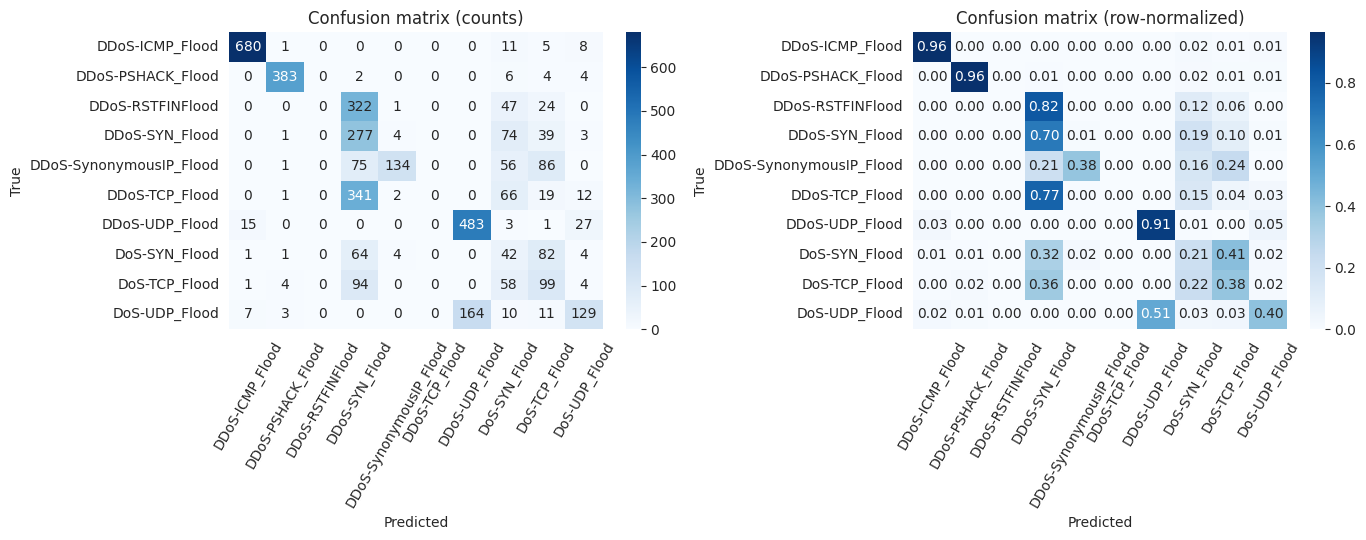

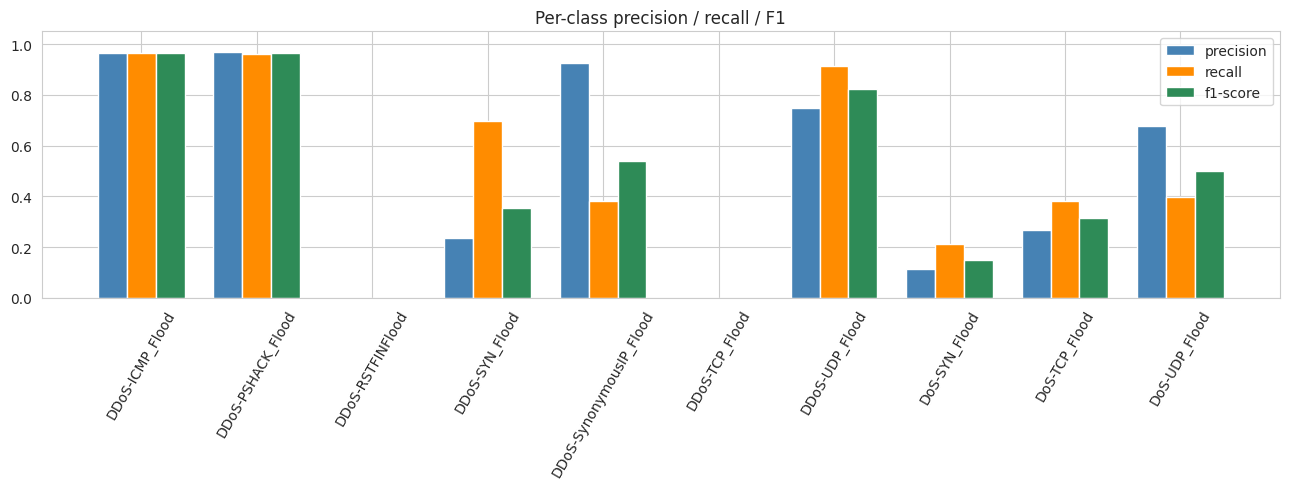

In [20]:
cm = confusion_matrix(y_true_test, y_pred_test, labels=range(N_CLASSES))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[0])
ax[0].set_title("Confusion matrix (counts)"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
ax[0].tick_params(axis="x", rotation=60)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[1])
ax[1].set_title("Confusion matrix (row-normalized)"); ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")
ax[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

prec, rec, f1, support = precision_recall_fscore_support(
    y_true_test, y_pred_test, labels=range(N_CLASSES), zero_division=0
)
x = np.arange(N_CLASSES); width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, prec, width, label="precision", color="steelblue")
ax.bar(x,          rec,  width, label="recall",    color="darkorange")
ax.bar(x + width,  f1,   width, label="f1-score",  color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=60)
ax.set_ylim(0, 1.05); ax.set_title("Per-class precision / recall / F1")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Conformal zero-day threshold calibration -- Algorithm 2
Using `conformal.py::calibrate_threshold` / `nonconformity_score` on the calibration split.

In [21]:
q_threshold, scores_sorted = calibrate_threshold(
    theta, A_cal, prototypes, forward_circuit, alpha=DEFAULT_ALPHA, device=device, batch_size=16,
)
print(f"Calibrated CQ-ZDR threshold q = {q_threshold:.4f}  (alpha={DEFAULT_ALPHA})")

Calibrated CQ-ZDR threshold q = 0.7518  (alpha=0.05)


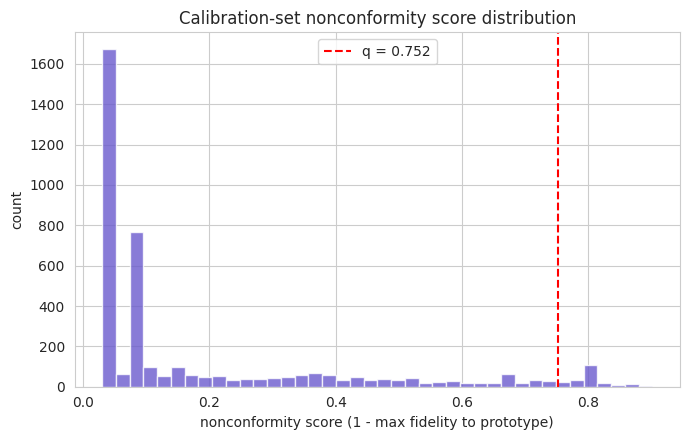

In [22]:
plt.figure(figsize=(7, 4.5))
plt.hist(scores_sorted, bins=40, color="slateblue", alpha=0.8)
plt.axvline(q_threshold, color="red", linestyle="--", label=f"q = {q_threshold:.3f}")
plt.xlabel("nonconformity score (1 - max fidelity to prototype)")
plt.ylabel("count")
plt.title("Calibration-set nonconformity score distribution")
plt.legend(); plt.tight_layout(); plt.show()

## 10. Unified inference with rejection -- Algorithm 3
Using `inference.py::estimate_lipschitz` and `qsnet_infer_batch` on the test split (known classes) and the zero-day split (unseen classes).

In [23]:
L_phi = estimate_lipschitz(A_train, theta, forward_circuit, n_probe=30, delta=0.05, device=device, batch_size=16)
print(f"Estimated Lipschitz constant L_phi = {L_phi:.4f}")

labels_test, radii_test, scores_test, _ = qsnet_infer_batch(
    A_test, theta, prototypes, q_threshold, forward_circuit,
    p=NOISE_P, L_phi=L_phi, Cf=DEFAULT_CF, zero_day=ZERO_DAY, device=device, batch_size=16,
)
labels_zday, radii_zday, scores_zday, _ = qsnet_infer_batch(
    A_zeroday, theta, prototypes, q_threshold, forward_circuit,
    p=NOISE_P, L_phi=L_phi, Cf=DEFAULT_CF, zero_day=ZERO_DAY, device=device, batch_size=16,
)

test_reject_rate  = float(np.mean(labels_test == ZERO_DAY))
zday_reject_rate  = float(np.mean(labels_zday == ZERO_DAY))
print(f"Test (known-class)  rejection rate: {test_reject_rate:.3f}  (want LOW)")
print(f"Zero-day (unseen)   rejection rate: {zday_reject_rate:.3f}  (want HIGH)")

Estimated Lipschitz constant L_phi = 3.9598
Test (known-class)  rejection rate: 0.047  (want LOW)
Zero-day (unseen)   rejection rate: 0.878  (want HIGH)


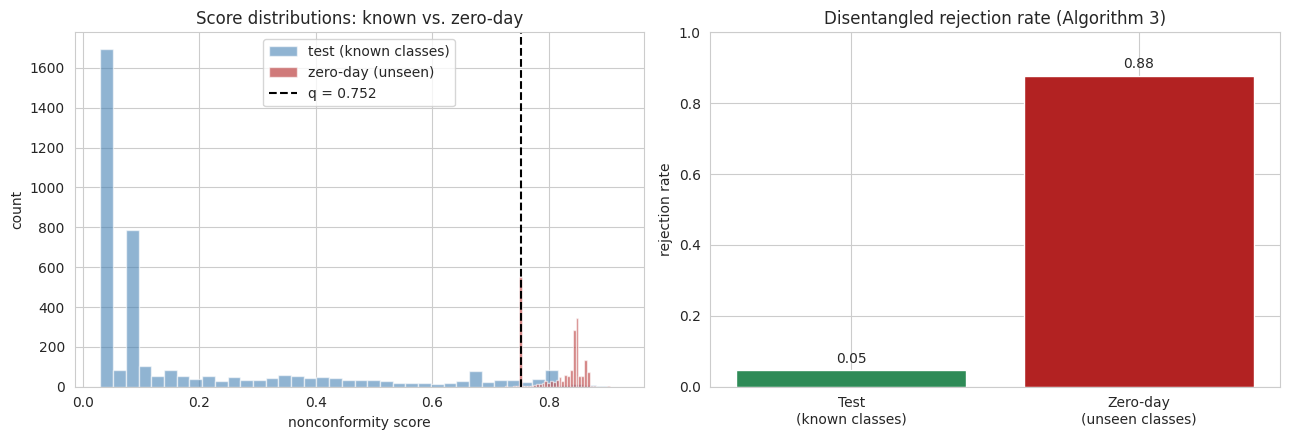

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].hist(scores_test, bins=40, alpha=0.6, label="test (known classes)", color="steelblue")
ax[0].hist(scores_zday, bins=40, alpha=0.6, label="zero-day (unseen)", color="firebrick")
ax[0].axvline(q_threshold, color="black", linestyle="--", label=f"q = {q_threshold:.3f}")
ax[0].set_xlabel("nonconformity score"); ax[0].set_ylabel("count")
ax[0].set_title("Score distributions: known vs. zero-day"); ax[0].legend()

bars = ax[1].bar(["Test\n(known classes)", "Zero-day\n(unseen classes)"],
                  [test_reject_rate, zday_reject_rate], color=["seagreen", "firebrick"])
ax[1].set_ylabel("rejection rate"); ax[1].set_ylim(0, 1)
ax[1].set_title("Disentangled rejection rate (Algorithm 3)")
for b in bars:
    ax[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f"{b.get_height():.2f}", ha="center")
plt.tight_layout(); plt.show()

## 11. Adversarial robustness: FGSM / PGD
Using `attacks.py::fgsm_attack`, `pgd_attack`, `eval_attacked`, `robustness_ablation`, and `train.py::train_plain_vqc` as the CE-only baseline.

[plain VQC] epoch 1/8 loss 1.5444
[plain VQC] epoch 2/8 loss 1.6106
[plain VQC] epoch 3/8 loss 1.7398
[plain VQC] epoch 4/8 loss 1.3932
[plain VQC] epoch 5/8 loss 0.9909
[plain VQC] epoch 6/8 loss 1.3447
[plain VQC] epoch 7/8 loss 1.1884
[plain VQC] epoch 8/8 loss 1.2663


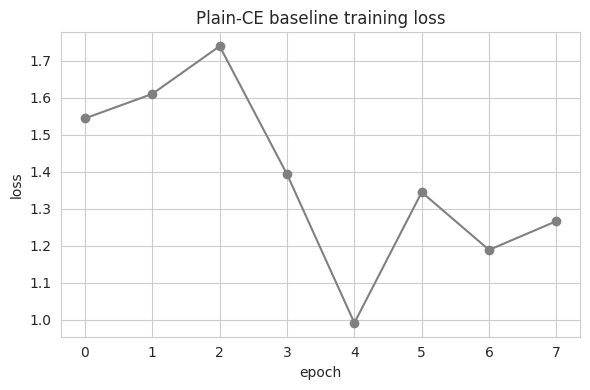

In [25]:
theta_plain, head_plain, plain_losses = train_plain_vqc(
    A_train, y_train, n_classes=N_CLASSES, n_qubits=N_QUBITS, n_layers=N_LAYERS,
    forward_circuit=forward_circuit, device=device, epochs=8, lr=LR, batch_size=BATCH_SIZE,
)

plt.figure(figsize=(6, 4))
plt.plot(plain_losses, marker="o", color="gray")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Plain-CE baseline training loss")
plt.tight_layout(); plt.show()

In [ ]:
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]

fgsm_results = robustness_ablation(
    A_test, y_test, theta, head, theta_plain, head_plain, forward_circuit,
    epsilons=epsilons, device=device, attack_fn=fgsm_attack, batch_size=16,
)
pgd_results = robustness_ablation(
    A_test, y_test, theta, head, theta_plain, head_plain, forward_circuit,
    epsilons=epsilons, device=device, attack_fn=pgd_attack, batch_size=16,
    alpha=0.03, steps=10,
)

df_fgsm = pd.DataFrame(fgsm_results)
df_pgd  = pd.DataFrame(pgd_results)
df_fgsm

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(df_fgsm["eps"], df_fgsm["maqt_acc"],  marker="o", label="MAQT")
ax[0].plot(df_fgsm["eps"], df_fgsm["plain_acc"], marker="s", label="Plain-CE baseline")
ax[0].set_xlabel("perturbation budget eps"); ax[0].set_ylabel("test accuracy")
ax[0].set_title("FGSM robustness curve"); ax[0].legend()

ax[1].plot(df_pgd["eps"], df_pgd["maqt_acc"],  marker="o", label="MAQT")
ax[1].plot(df_pgd["eps"], df_pgd["plain_acc"], marker="s", label="Plain-CE baseline")
ax[1].set_xlabel("perturbation budget eps"); ax[1].set_ylabel("test accuracy")
ax[1].set_title("PGD (10-step) robustness curve"); ax[1].legend()

plt.tight_layout(); plt.show()

maqt_gain = df_fgsm["maqt_acc"].iloc[-1] - df_fgsm["plain_acc"].iloc[-1]
print(f"MAQT vs plain-CE accuracy gain at strongest FGSM budget: {maqt_gain:+.3f}")

## 12. Lambda1 / Lambda2 hyperparameter sweep
Using `sweep.py::run_sweep` + `default_score_fn`, wrapping `train_maqt` so its return signature `(theta, head, prototypes, ema_protos, history)` matches what `run_sweep` expects.

In [ ]:
def train_fn(lambda1_max, lambda2_max, epochs=6):
    return train_maqt(
        A_train, y_train, n_classes=N_CLASSES, n_qubits=N_QUBITS, n_layers=N_LAYERS,
        forward_circuit=forward_circuit, device=device,
        epochs=epochs, lr=LR, batch_size=BATCH_SIZE,
        lambda1_max=lambda1_max, lambda2_max=lambda2_max,
        use_weighted_sampler=True, verbose=False,
    )

param_grid = [
    {"lambda1_max": l1, "lambda2_max": l2}
    for l1 in (0.1, 0.5)
    for l2 in (0.02, 0.5)
]

df_sweep = run_sweep(train_fn, param_grid, default_score_fn)
df_sweep

In [ ]:
best_row = df_sweep.iloc[0]
print(f"Recommended operating point: lambda1={best_row['lambda1_max']}, lambda2={best_row['lambda2_max']}, "
      f"score={best_row['score']:.4f}")

LAMBDA1_MAX = float(best_row["lambda1_max"])
LAMBDA2_MAX = float(best_row["lambda2_max"])

pivot_score = df_sweep.pivot(index="lambda2_max", columns="lambda1_max", values="score")
pivot_td    = df_sweep.pivot(index="lambda2_max", columns="lambda1_max", values="final_intra_fid")
pivot_fid   = df_sweep.pivot(index="lambda2_max", columns="lambda1_max", values="min_grad_var")

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
sns.heatmap(pivot_score, annot=True, fmt=".2f", cmap="viridis", ax=ax[0]); ax[0].set_title("Combined score"); ax[0].invert_yaxis()
sns.heatmap(pivot_td, annot=True, fmt=".2f", cmap="crest", ax=ax[1]); ax[1].set_title("Final intra-class fidelity"); ax[1].invert_yaxis()
sns.heatmap(pivot_fid, annot=True, fmt=".1e", cmap="magma", ax=ax[2]); ax[2].set_title("Min gradient variance"); ax[2].invert_yaxis()
plt.tight_layout(); plt.show()

## 13. Final retrain with tuned hyperparameters + save checkpoint & logs
Using `logging.py::write_history_log` / `write_sweep_log`.

In [26]:
#print(f"Using tuned hyperparameters: lambda1_max={LAMBDA1_MAX}, lambda2_max={LAMBDA2_MAX}")
LAMBDA1_MAX = 0.66  #by previous expts i put these max min values, so you can comment it out when urs expt with this dataset
LAMBDA1_MAX = 0.5
theta_final, head_final, prototypes_final, ema_protos_final, history_final = train_maqt(
    A_train, y_train, n_classes=N_CLASSES, n_qubits=N_QUBITS, n_layers=N_LAYERS,
    forward_circuit=forward_circuit, device=device,
    epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    lambda1_max=LAMBDA1_MAX, lambda2_max=LAMBDA2_MAX,
    use_weighted_sampler=True, log_every=1, verbose=True,
)

final_report = hilbert_geometry_diagnostics(
    theta_final, A_test, y_test, prototypes_final, forward_circuit,
    class_names=CLASS_NAMES, device=device, batch_size=16,
)
print_h1_report(final_report)

y_true_final, y_pred_final = predict_labels(A_test, y_test, theta_final, head_final, forward_circuit, device=device, batch_size=16)
print("\nFinal classification report:")
print(classification_report(y_true_final, y_pred_final, target_names=CLASS_NAMES, zero_division=0))

epoch  1/10 | loss 2.0206 | L_CE 2.0206 | L_intra 0.4047 | L_inter -0.5943 | grad_var 1.02e-03 | intra_fid 0.595 | inter_TD 0.576 | time 50.0s
epoch  2/10 | loss 1.5043 | L_CE 1.5086 | L_intra 0.3285 | L_inter -0.5767 | grad_var 2.80e-03 | intra_fid 0.672 | inter_TD 0.594 | time 50.9s
epoch  3/10 | loss 1.3641 | L_CE 1.3753 | L_intra 0.3315 | L_inter -0.5897 | grad_var 4.85e-03 | intra_fid 0.669 | inter_TD 0.570 | time 50.7s
epoch  4/10 | loss 1.2269 | L_CE 1.2445 | L_intra 0.3194 | L_inter -0.5911 | grad_var 5.19e-03 | intra_fid 0.681 | inter_TD 0.613 | time 50.8s
epoch  5/10 | loss 1.1858 | L_CE 1.2133 | L_intra 0.3005 | L_inter -0.5927 | grad_var 5.91e-03 | intra_fid 0.700 | inter_TD 0.588 | time 51.1s
epoch  6/10 | loss 1.2238 | L_CE 1.2388 | L_intra 0.3235 | L_inter -0.5892 | grad_var 7.06e-03 | intra_fid 0.677 | inter_TD 0.592 | time 50.7s
epoch  7/10 | loss 1.2094 | L_CE 1.2266 | L_intra 0.3166 | L_inter -0.5850 | grad_var 8.36e-03 | intra_fid 0.683 | inter_TD 0.576 | time 50.7s

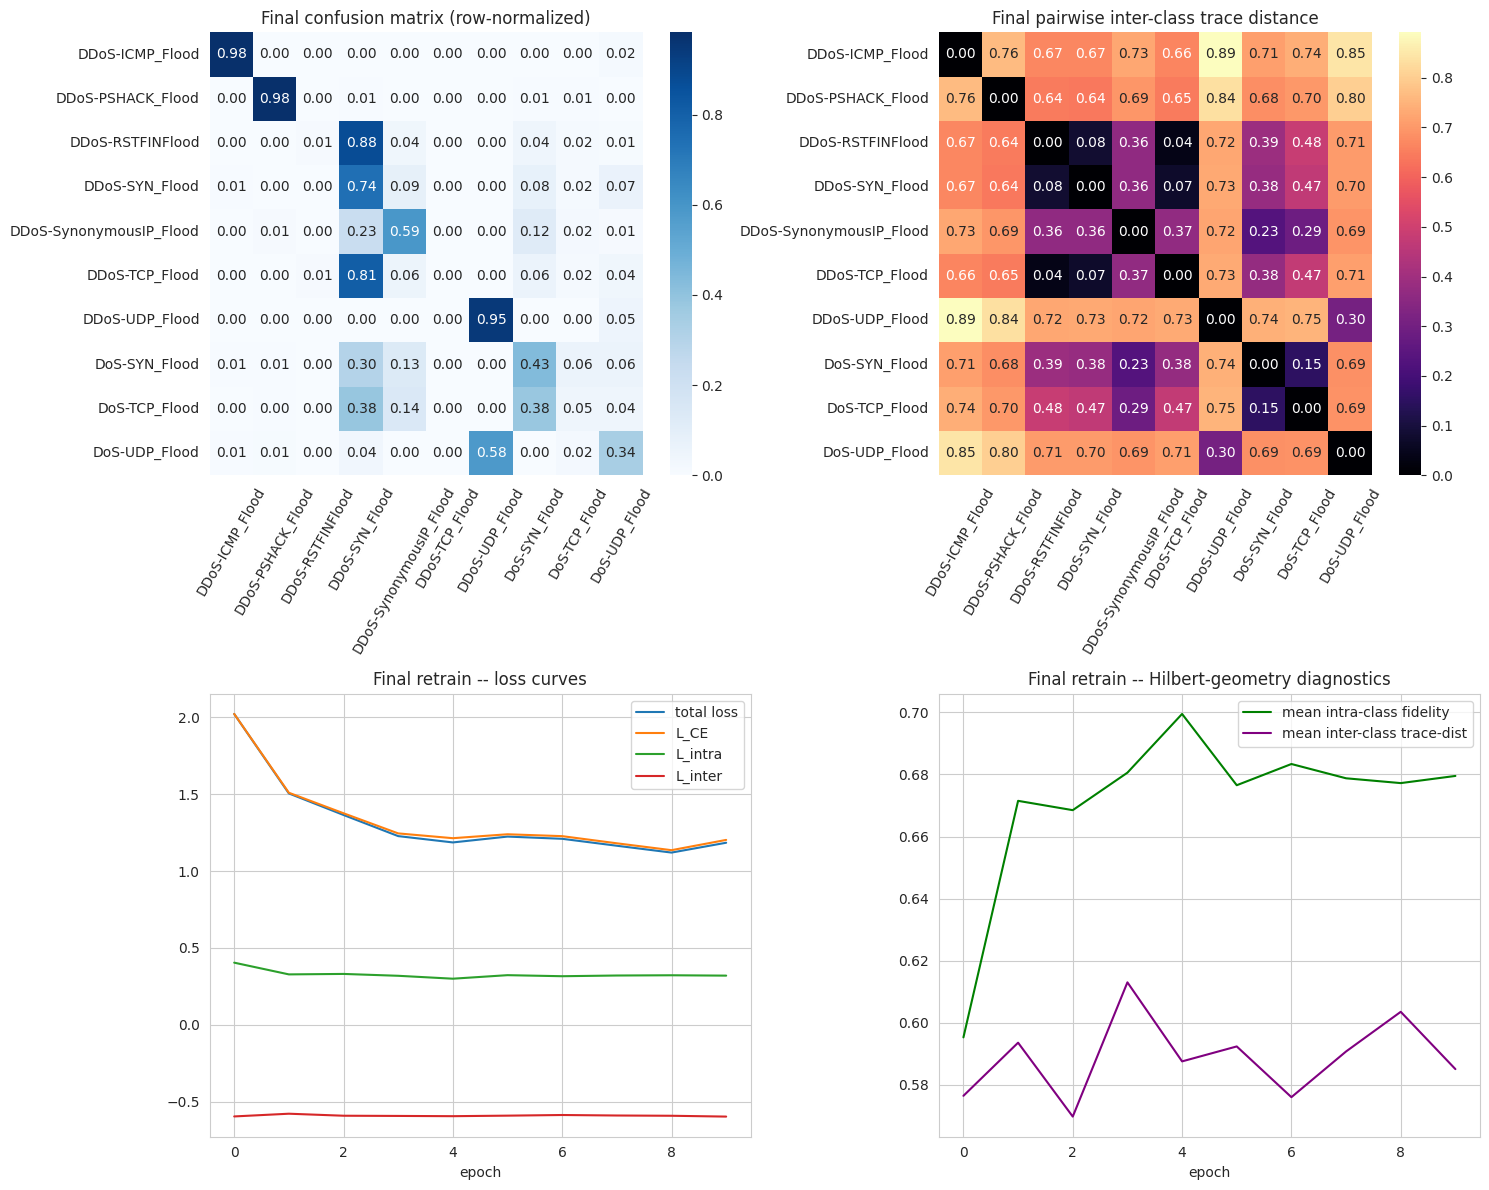

In [27]:
final_cm = confusion_matrix(y_true_final, y_pred_final, labels=range(N_CLASSES))
final_cm_norm = final_cm.astype(float) / (final_cm.sum(axis=1, keepdims=True) + 1e-9)

class_ids = sorted(prototypes_final)
n = len(class_ids)
final_td_matrix = np.zeros((n, n))
for i, ci in enumerate(class_ids):
    for j, cj in enumerate(class_ids):
        if i != j:
            final_td_matrix[i, j] = float(trace_distance(prototypes_final[ci], prototypes_final[cj]))
labels = [CLASS_NAMES[c] for c in class_ids]

fig, ax = plt.subplots(2, 2, figsize=(15, 12))

sns.heatmap(final_cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[0, 0])
ax[0, 0].set_title("Final confusion matrix (row-normalized)"); ax[0, 0].tick_params(axis="x", rotation=60)

sns.heatmap(final_td_matrix, annot=True, fmt=".2f", cmap="magma", xticklabels=labels, yticklabels=labels, ax=ax[0, 1])
ax[0, 1].set_title("Final pairwise inter-class trace distance"); ax[0, 1].tick_params(axis="x", rotation=60)

ax[1, 0].plot(history_final["loss"], label="total loss")
ax[1, 0].plot(history_final["L_CE"], label="L_CE")
ax[1, 0].plot(history_final["L_intra"], label="L_intra")
ax[1, 0].plot(history_final["L_inter"], label="L_inter")
ax[1, 0].set_title("Final retrain -- loss curves"); ax[1, 0].set_xlabel("epoch"); ax[1, 0].legend()

ax[1, 1].plot(history_final["intra_fid_gap"], label="mean intra-class fidelity", color="green")
ax[1, 1].plot(history_final["inter_trace_dist"], label="mean inter-class trace-dist", color="purple")
ax[1, 1].set_title("Final retrain -- Hilbert-geometry diagnostics"); ax[1, 1].set_xlabel("epoch"); ax[1, 1].legend()

plt.tight_layout(); plt.show()

In [28]:
# --- recalibrate conformal threshold + save everything ---
q_final, _ = calibrate_threshold(theta_final, A_cal, prototypes_final, forward_circuit, alpha=DEFAULT_ALPHA, device=device, batch_size=16)

ckpt_dir = "/kaggle/working/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

checkpoint = {
    "theta": theta_final.detach().cpu(),
    "head_state_dict": head_final.state_dict(),
    "N_QUBITS": N_QUBITS, "N_LAYERS": N_LAYERS, "NOISE_P": NOISE_P,
    "lambda1_max": LAMBDA1_MAX, "lambda2_max": LAMBDA2_MAX,
    "q_threshold": q_final,
    "history": history_final,
    "scaler_mean": scaler.mean_, "scaler_scale": scaler.scale_,
    "pca_components": pca.components_, "pca_mean": pca.mean_,
    "class_names": CLASS_NAMES,
    "label_encoder_classes": le.classes_,
}
ckpt_path = os.path.join(ckpt_dir, "maqt_final.pt")
torch.save(checkpoint, ckpt_path)
print(f"Saved checkpoint -> {ckpt_path}")

proto_export = {c: rho.detach().cpu().numpy() for c, rho in prototypes_final.items()}
proto_path = "/kaggle/working/prototypes_final.pkl"
with open(proto_path, "wb") as f:
    pickle.dump({"prototypes": proto_export, "class_names": CLASS_NAMES}, f)
print(f"Saved prototypes -> {proto_path}")

write_history_log(history_final, name="maqt_final", extra={"lambda1_max": LAMBDA1_MAX, "lambda2_max": LAMBDA2_MAX, "q_threshold": q_final}, log_dir="/kaggle/working/logs")
write_sweep_log(df_sweep, name="lambda_sweep", log_dir="/kaggle/working/logs/sweeps")
print("Wrote training-history and sweep logs to /kaggle/working/logs")

Saved checkpoint -> /kaggle/working/checkpoints/maqt_final.pt
Saved prototypes -> /kaggle/working/prototypes_final.pkl


NameError: name 'df_sweep' is not defined

In [29]:
print("=== SUMMARY ===")
print(f"Classes used ({N_CLASSES}): {CLASS_NAMES}")
print(f"Final train loss:        {history_final['loss'][-1]:.4f}")
print(f"Final intra-class fid:   {history_final['intra_fid_gap'][-1]:.4f}")
print(f"Final inter-class TD:    {history_final['inter_trace_dist'][-1]:.4f}")
print(f"Min grad variance seen:  {min(history_final['grad_var']):.2e}")
print(f"Conformal threshold q:   {q_final:.4f}")
print(f"Test rejection rate:     {test_reject_rate:.3f}  (known classes, want low)")
print(f"Zero-day rejection rate: {zday_reject_rate:.3f}  (unseen classes, want high)")

=== SUMMARY ===
Classes used (10): [np.str_('DDoS-ICMP_Flood'), np.str_('DDoS-PSHACK_Flood'), np.str_('DDoS-RSTFINFlood'), np.str_('DDoS-SYN_Flood'), np.str_('DDoS-SynonymousIP_Flood'), np.str_('DDoS-TCP_Flood'), np.str_('DDoS-UDP_Flood'), np.str_('DoS-SYN_Flood'), np.str_('DoS-TCP_Flood'), np.str_('DoS-UDP_Flood')]
Final train loss:        1.1838
Final intra-class fid:   0.6795
Final inter-class TD:    0.5851
Min grad variance seen:  1.02e-03
Conformal threshold q:   0.7844
Test rejection rate:     0.047  (known classes, want low)
Zero-day rejection rate: 0.878  (unseen classes, want high)


In [30]:
print("hello")

hello


In [31]:
# ===================== Day 15: Depolarizing channel Λ_p + Proposition 1 =====================

def depolarizing_channel_global(rho, p):
    """
    Global depolarizing channel: Λ_p(ρ) = (1-p)·ρ + p·I/d
    This is the idealized channel Proposition 1 is stated for (exact (1-p) trace-distance contraction).
    NOTE: circuit.py applies a *local, per-qubit* DepolarizingChannel(NOISE_P) inside build_forward_circuit
    as the NISQ-noise model -- that's a good hardware approximation but does not satisfy this exact identity.
    This cell validates the idealized global channel used by the theory; NOISE_P is the same p in both roles.
    """
    d = rho.shape[-1]
    I = torch.eye(d, dtype=rho.dtype, device=rho.device)
    return (1.0 - p) * rho + p * I / d


def random_density_matrix(dim, rng):
    """Ginibre-ensemble random density matrix of the given Hilbert-space dimension."""
    A = rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))
    A = torch.tensor(A, dtype=torch.cdouble)
    rho = A @ A.conj().T
    return rho / torch.trace(rho).real


DIM = 2 ** N_QUBITS
_rng = np.random.default_rng(SEED)
N_PAIRS_P1 = 25
p_values = np.linspace(0.0, 1.0, 11)

prop1_records = []
for _ in range(N_PAIRS_P1):
    rho = random_density_matrix(DIM, _rng)
    sigma = random_density_matrix(DIM, _rng)
    d_rho_sigma = float(trace_distance(rho, sigma))
    for p in p_values:
        rho_p = depolarizing_channel_global(rho, p)
        sigma_p = depolarizing_channel_global(sigma, p)
        d_measured = float(trace_distance(rho_p, sigma_p))
        d_theory = (1.0 - p) * d_rho_sigma
        prop1_records.append({"p": p, "D_tr_measured": d_measured,
                               "D_tr_theory": d_theory, "abs_error": abs(d_measured - d_theory)})

df_prop1 = pd.DataFrame(prop1_records)
prop1_summary = df_prop1.groupby("p")["abs_error"].agg(["mean", "max"]).reset_index()
print("Proposition 1 check: D_tr(Λ_p(ρ),Λ_p(σ)) = (1-p)·D_tr(ρ,σ)")
print(prop1_summary.to_string(index=False))
print(f"\nMax absolute error across all (p, ρ, σ): {df_prop1['abs_error'].max():.2e}  (should be ~0 up to fp precision)")

Proposition 1 check: D_tr(Λ_p(ρ),Λ_p(σ)) = (1-p)·D_tr(ρ,σ)
  p         mean          max
0.0 0.000000e+00 0.000000e+00
0.1 1.421085e-16 4.440892e-16
0.2 1.465494e-16 3.885781e-16
0.3 1.265654e-16 5.551115e-16
0.4 1.287859e-16 3.885781e-16
0.5 7.771561e-17 1.665335e-16
0.6 7.771561e-17 2.220446e-16
0.7 5.440093e-17 1.110223e-16
0.8 4.218847e-17 9.714451e-17
0.9 1.998401e-17 5.551115e-17
1.0 0.000000e+00 0.000000e+00

Max absolute error across all (p, ρ, σ): 5.55e-16  (should be ~0 up to fp precision)


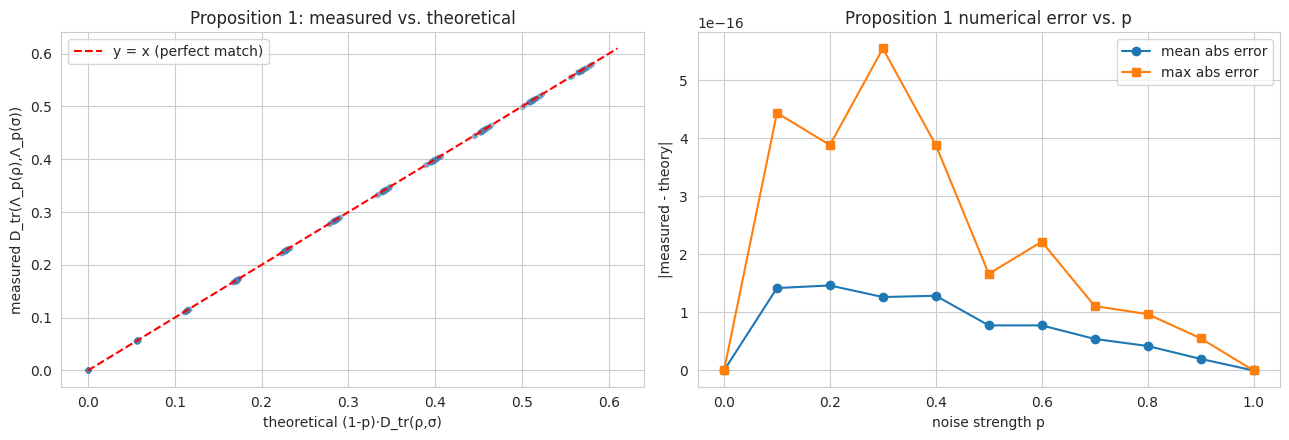

p is exposed as:
  - NISQ-noise model -> circuit.py's DepolarizingChannel(NOISE_P, wires=w) inside build_forward_circuit
  - regulariser knob -> NOISE_P passed as `p` into qsnet_infer_batch / certified radius (Algorithm 3, line 8)


In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].scatter(df_prop1["D_tr_theory"], df_prop1["D_tr_measured"], s=10, alpha=0.4, color="steelblue")
lims = [0, df_prop1["D_tr_theory"].max() * 1.05]
ax[0].plot(lims, lims, "r--", label="y = x (perfect match)")
ax[0].set_xlabel("theoretical (1-p)·D_tr(ρ,σ)"); ax[0].set_ylabel("measured D_tr(Λ_p(ρ),Λ_p(σ))")
ax[0].set_title("Proposition 1: measured vs. theoretical"); ax[0].legend()

ax[1].plot(prop1_summary["p"], prop1_summary["mean"], marker="o", label="mean abs error")
ax[1].plot(prop1_summary["p"], prop1_summary["max"], marker="s", label="max abs error")
ax[1].set_xlabel("noise strength p"); ax[1].set_ylabel("|measured - theory|")
ax[1].set_title("Proposition 1 numerical error vs. p"); ax[1].legend()

plt.tight_layout(); plt.show()

print("p is exposed as:")
print("  - NISQ-noise model -> circuit.py's DepolarizingChannel(NOISE_P, wires=w) inside build_forward_circuit")
print("  - regulariser knob -> NOISE_P passed as `p` into qsnet_infer_batch / certified radius (Algorithm 3, line 8)")

In [34]:

from scripts.utils import to_torch_batch_x
def estimate_lipschitz_pairs(X, theta, forward_circuit, n_pairs=300, min_dist=1e-4,
                              device=None, batch_size=64, seed=SEED):
    """
    Empirical Lipschitz ratio D_tr(phi(x1),phi(x2)) / ||x1-x2|| over randomly sampled input pairs.
    Returns the array of per-pair ratios (take np.percentile(ratios, 95) as the L_phi estimate).
    """
    X_np = np.asarray(X, dtype=np.float32)
    n = len(X_np)
    rng = np.random.default_rng(seed)

    idx1 = rng.integers(0, n, size=n_pairs * 3)
    idx2 = rng.integers(0, n, size=n_pairs * 3)
    keep = idx1 != idx2
    idx1, idx2 = idx1[keep], idx2[keep]
    dists = np.linalg.norm(X_np[idx1] - X_np[idx2], axis=1)
    keep2 = dists > min_dist
    idx1, idx2, dists = idx1[keep2][:n_pairs], idx2[keep2][:n_pairs], dists[keep2][:n_pairs]

    ratios = []
    with torch.no_grad():
        for i in range(0, len(idx1), batch_size):
            x1 = to_torch_batch_x(X_np[idx1[i:i + batch_size]], device=device)
            x2 = to_torch_batch_x(X_np[idx2[i:i + batch_size]], device=device)
            _, rho1 = forward_circuit(x1, theta)
            _, rho2 = forward_circuit(x2, theta)
            for k in range(rho1.shape[0]):
                d_out = float(trace_distance(rho1[k], rho2[k]))
                ratios.append(d_out / dists[i + k])
    return np.array(ratios)


lipschitz_results = {}
for name, X_ds in [("train", A_train), ("test", A_test), ("cal", A_cal), ("zeroday", A_zeroday)]:
    n_pairs = min(300, len(X_ds) // 2)
    ratios = estimate_lipschitz_pairs(X_ds, theta_final, forward_circuit, n_pairs=n_pairs,
                                       device=device, batch_size=16, seed=SEED)
    lipschitz_results[name] = {
        "ratios": ratios,
        "L_phi_50": float(np.percentile(ratios, 50)),
        "L_phi_95": float(np.percentile(ratios, 95)),
        "L_phi_99": float(np.percentile(ratios, 99)),
        "L_phi_max": float(np.max(ratios)),
    }
    r = lipschitz_results[name]
    print(f"{name:8s}: n_pairs={len(ratios):4d}  L_phi(95th)={r['L_phi_95']:.4f}  "
          f"median={r['L_phi_50']:.4f}  max={r['L_phi_max']:.4f}")

train   : n_pairs= 300  L_phi(95th)=0.7582  median=0.5503  max=0.8495
test    : n_pairs= 300  L_phi(95th)=0.7648  median=0.5608  max=0.8407
cal     : n_pairs= 300  L_phi(95th)=0.7739  median=0.5950  max=0.8668
zeroday : n_pairs= 300  L_phi(95th)=0.7400  median=0.5626  max=0.8126


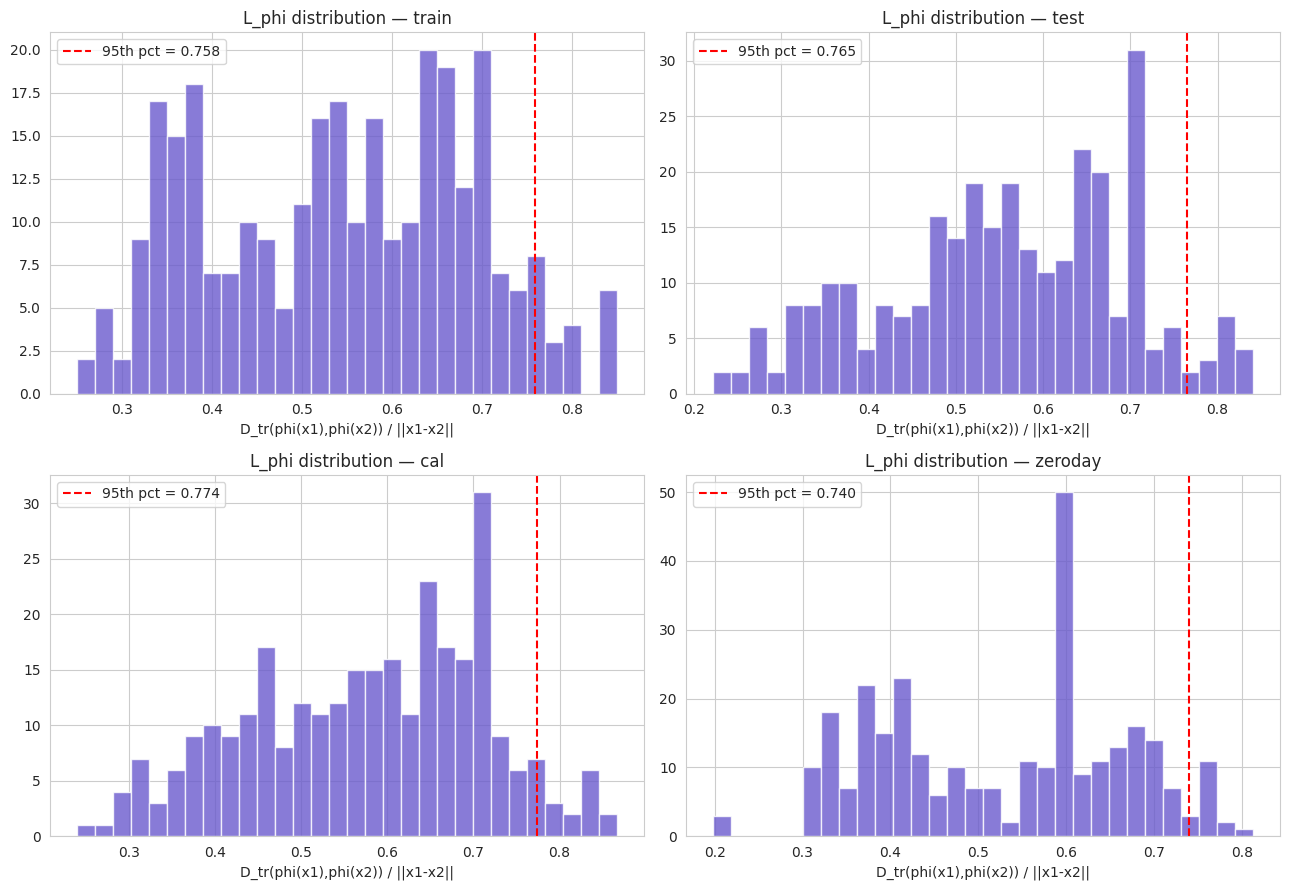

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, res) in zip(axes.flat, lipschitz_results.items()):
    ax.hist(res["ratios"], bins=30, color="slateblue", alpha=0.8)
    ax.axvline(res["L_phi_95"], color="red", linestyle="--", label=f"95th pct = {res['L_phi_95']:.3f}")
    ax.set_title(f"L_phi distribution — {name}")
    ax.set_xlabel("D_tr(phi(x1),phi(x2)) / ||x1-x2||"); ax.legend()
plt.tight_layout(); plt.show()

In [36]:

# Algorithm 3 already computes R = margin / (2*(1-p)*L_phi*Cf) inside qsnet_infer_batch;
# here we plug in the Day-16 per-dataset 95th-percentile L_phi (test set) instead of the
# default probe-based estimate, then look at the radius distribution on correctly-classified,
# accepted test samples.

L_phi_test = lipschitz_results["test"]["L_phi_95"]

labels_test_cert, radii_test_cert, scores_test_cert, fmaps_test_cert = qsnet_infer_batch(
    A_test, theta_final, prototypes_final, q_final, forward_circuit,
    p=NOISE_P, L_phi=L_phi_test, Cf=DEFAULT_CF, zero_day=ZERO_DAY, device=device, batch_size=16,
)

correct_mask = (labels_test_cert == y_test)          # excludes both misclassifications and rejections
certified_radii_correct = radii_test_cert[correct_mask]

print(f"L_phi used (test, 95th pct): {L_phi_test:.4f}")
print(f"Correctly-classified & accepted test samples: {correct_mask.sum()} / {len(y_test)}")
print(f"Certified radius R: mean={certified_radii_correct.mean():.4f}  "
      f"median={np.median(certified_radii_correct):.4f}  "
      f"min={certified_radii_correct.min():.4f}  max={certified_radii_correct.max():.4f}")

L_phi used (test, 95th pct): 0.7648
Correctly-classified & accepted test samples: 2225 / 4000
Certified radius R: mean=0.1721  median=0.1461  min=0.0000  max=0.3275


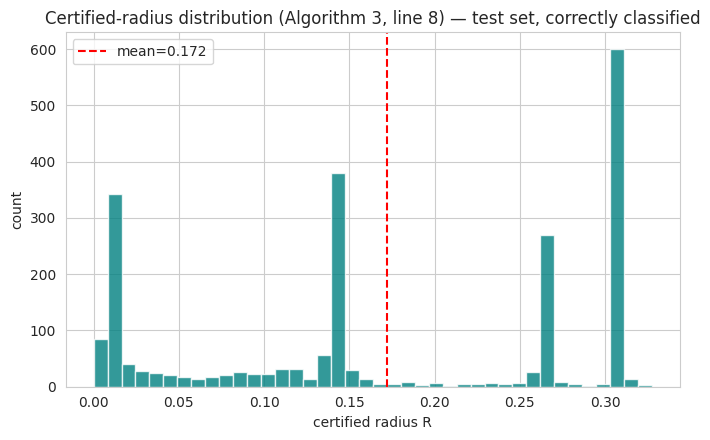


[final model] zero-day rejection rate: 0.668


In [37]:
plt.figure(figsize=(7, 4.5))
plt.hist(certified_radii_correct, bins=40, color="teal", alpha=0.8)
plt.axvline(certified_radii_correct.mean(), color="red", linestyle="--",
            label=f"mean={certified_radii_correct.mean():.3f}")
plt.xlabel("certified radius R"); plt.ylabel("count")
plt.title("Certified-radius distribution (Algorithm 3, line 8) — test set, correctly classified")
plt.legend(); plt.tight_layout(); plt.show()

# also recompute zero-day inference under the FINAL model for Day-18 consistency
labels_zday_final, radii_zday_final, scores_zday_final, fmaps_zday_final = qsnet_infer_batch(
    A_zeroday, theta_final, prototypes_final, q_final, forward_circuit,
    p=NOISE_P, L_phi=lipschitz_results["zeroday"]["L_phi_95"], Cf=DEFAULT_CF,
    zero_day=ZERO_DAY, device=device, batch_size=16,
)
print(f"\n[final model] zero-day rejection rate: {float(np.mean(labels_zday_final == ZERO_DAY)):.3f}")

In [39]:


def g_transform(F, kind="identity"):
    """
    Map fidelity F in [0,1] into the quantity used inside the Proposition-2 gap formula.
      - "identity": g(F) = F        matches the margin term already used in Algorithm 3
                                     (inference.py: sorted_f[0]-sorted_f[1])
      - "sqrt1mf" : g(F) = sqrt(1-F) Fuchs-van de Graaf trace-distance upper bound, dimensionally
                                     consistent with L_phi (estimated w.r.t. trace distance in Day 16)
    Swap in the exact g(.) from your Proposition-2 write-up if it differs from these two.
    """
    F = np.clip(np.asarray(F, dtype=float), 0.0, 1.0)
    if kind == "identity":
        return F
    if kind == "sqrt1mf":
        return np.sqrt(1.0 - F)
    raise ValueError(kind)


# F_in: fidelity of correctly-classified, accepted test samples to their OWN (true-class) prototype
F_in = 1.0 - scores_test_cert[correct_mask]

# F_out: max fidelity of zero-day (unseen-class) samples to their NEAREST prototype
F_out = 1.0 - scores_zday_final

print(f"F_in  (known-class, correct):  n={len(F_in):4d}  mean={F_in.mean():.4f}  "
      f"median={np.median(F_in):.4f}  p05={np.percentile(F_in, 5):.4f}")
print(f"F_out (zero-day, nearest):     n={len(F_out):4d}  mean={F_out.mean():.4f}  "
      f"median={np.median(F_out):.4f}  p95={np.percentile(F_out, 95):.4f}")

# conservative Lipschitz bound: worst case across the two datasets involved
L_phi_eps = max(lipschitz_results["test"]["L_phi_95"], lipschitz_results["zeroday"]["L_phi_95"])

def separable_budget_gap(F_in_val, F_out_val, L_phi, p=NOISE_P, kind="identity"):
    return (g_transform(F_in_val, kind) - g_transform(F_out_val, kind)) / (2.0 * (1.0 - p) * L_phi)

eps_records = []
for kind in ("identity", "sqrt1mf"):
    for stat_name, f_in_val, f_out_val in [
        ("mean",       F_in.mean(),            F_out.mean()),
        ("median",     np.median(F_in),        np.median(F_out)),
        ("worst_case", np.percentile(F_in, 5), np.percentile(F_out, 95)),
    ]:
        eps_star = separable_budget_gap(f_in_val, f_out_val, L_phi_eps, p=NOISE_P, kind=kind)
        eps_records.append({"g(.)": kind, "statistic": stat_name,
                             "F_in": f_in_val, "F_out": f_out_val, "epsilon_star": eps_star})

df_eps = pd.DataFrame(eps_records)
print("\nPredicted separable-budget gap ε* = (g(F_in) - g(F_out)) / (2(1-p)L_phi):")
print(df_eps.to_string(index=False))

F_in  (known-class, correct):  n=2225  mean=0.8408  median=0.9055  p05=0.3450
F_out (zero-day, nearest):     n=2000  mean=0.2072  median=0.1928  p95=0.2654

Predicted separable-budget gap ε* = (g(F_in) - g(F_out)) / (2(1-p)L_phi):
    g(.)  statistic     F_in    F_out  epsilon_star
identity       mean 0.840801 0.207188      0.418416
identity     median 0.905505 0.192805      0.470642
identity worst_case 0.345027 0.265449      0.052550
 sqrt1mf       mean 0.840801 0.207188     -0.324505
 sqrt1mf     median 0.905505 0.192805     -0.390302
 sqrt1mf worst_case 0.345027 0.265449     -0.031536


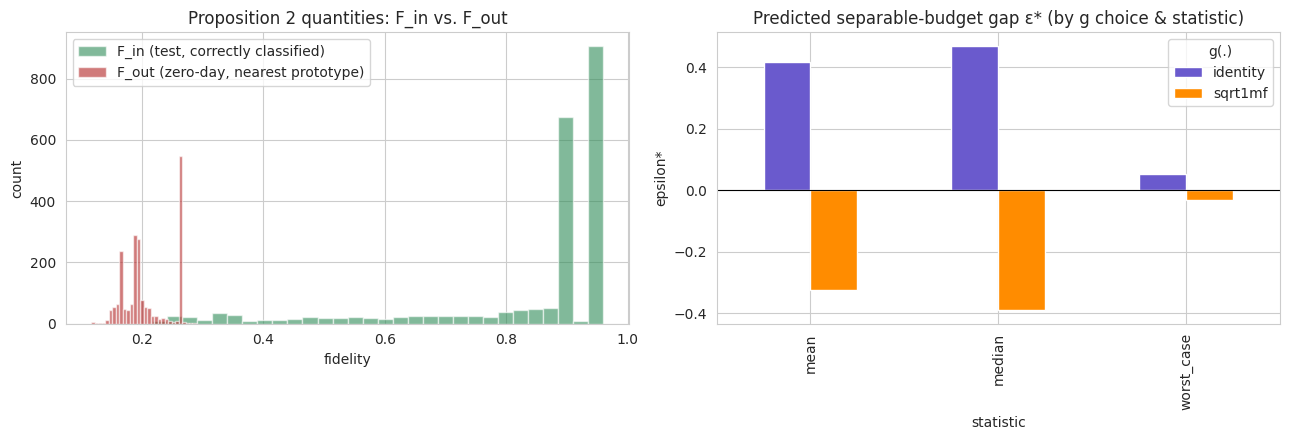


All epsilon* > 0 (separable budget exists under every g/statistic combo): False


In [40]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].hist(F_in, bins=30, alpha=0.6, label="F_in (test, correctly classified)", color="seagreen")
ax[0].hist(F_out, bins=30, alpha=0.6, label="F_out (zero-day, nearest prototype)", color="firebrick")
ax[0].set_xlabel("fidelity"); ax[0].set_ylabel("count")
ax[0].set_title("Proposition 2 quantities: F_in vs. F_out"); ax[0].legend()

pivot_eps = df_eps.pivot(index="statistic", columns="g(.)", values="epsilon_star")
pivot_eps.plot(kind="bar", ax=ax[1], color=["slateblue", "darkorange"])
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].set_ylabel("epsilon*"); ax[1].set_title("Predicted separable-budget gap ε* (by g choice & statistic)")
ax[1].legend(title="g(.)")
plt.tight_layout(); plt.show()

sep_ok = (df_eps["epsilon_star"] > 0).all()
print(f"\nAll epsilon* > 0 (separable budget exists under every g/statistic combo): {sep_ok}")

In [41]:
theory_validation = {
    "prop1_max_abs_error": float(df_prop1["abs_error"].max()),
    "lipschitz_per_dataset": {
        name: {k: v for k, v in res.items() if k != "ratios"}
        for name, res in lipschitz_results.items()
    },
    "certified_radius": {
        "n_correct_accepted": int(correct_mask.sum()),
        "mean": float(certified_radii_correct.mean()),
        "median": float(np.median(certified_radii_correct)),
        "min": float(certified_radii_correct.min()),
        "max": float(certified_radii_correct.max()),
    },
    "F_in_stats": {"mean": float(F_in.mean()), "median": float(np.median(F_in)), "p05": float(np.percentile(F_in, 5))},
    "F_out_stats": {"mean": float(F_out.mean()), "median": float(np.median(F_out)), "p95": float(np.percentile(F_out, 95))},
    "epsilon_star": df_eps.to_dict(orient="records"),
}

log_dir = "/kaggle/working/logs"
os.makedirs(log_dir, exist_ok=True)
with open(os.path.join(log_dir, "theory_validation_day15_18.json"), "w") as f:
    json.dump(to_jsonable(theory_validation), f, indent=2)

print("Saved theory-validation results -> /kaggle/working/logs/theory_validation_day15_18.json")

Saved theory-validation results -> /kaggle/working/logs/theory_validation_day15_18.json
